DECISION TREE

In [2]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.feature_selection import f_classif,chi2
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [3]:
#loading the dataset
df=pd.read_excel("heart_disease.xlsx",sheet_name="Heart_disease")

In [4]:
df.shape

(908, 13)

In [5]:
df.info

<bound method DataFrame.info of      age   sex               cp  trestbps  chol    fbs           restecg  \
0     63  Male   typical angina       145   233   True    lv hypertrophy   
1     41  Male  atypical angina       135   203  False            normal   
2     57  Male     asymptomatic       140   192  False            normal   
3     52  Male   typical angina       118   186  False    lv hypertrophy   
4     57  Male     asymptomatic       110   201  False            normal   
..   ...   ...              ...       ...   ...    ...               ...   
903   53  Male     asymptomatic       125     0  False            normal   
904   62  Male     asymptomatic       166   170  False  st-t abnormality   
905   56  Male      non-anginal       170     0  False    lv hypertrophy   
906   56  Male      non-anginal       144   208   True  st-t abnormality   
907   57  Male     asymptomatic       142   277   True  st-t abnormality   

     thalch  exang  oldpeak        slope               

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [7]:
# Check missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
# Replacing Numerical columns missing values with mean
num_cols = df.select_dtypes(include=['float64','int64']).columns # selecting numerical columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())# Numerical → replace with mean

In [9]:
df.isnull().sum() # missing values replaced

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [10]:
# Checking for duplicates
df.duplicated().sum()

np.int64(1)

In [11]:
# droping the duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum() # shows duplicated values are removed

np.int64(0)

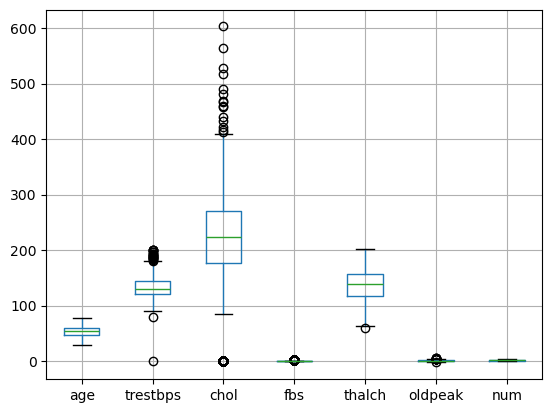

In [12]:
# checking for outliers
df.boxplot()
plt.show()

In [13]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

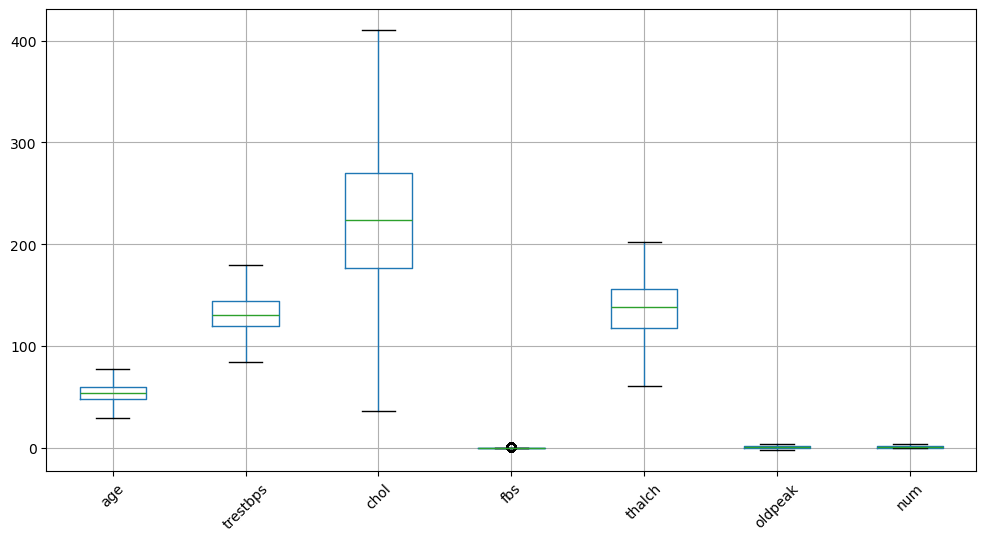

In [14]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()# shows outliers are treated

In [15]:
df.describe() # statistical summary

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,53.787211,133.264609,207.232359,135.977949,0.882533,1.007718
std,9.162016,19.303104,97.148377,26.809967,1.020365,1.144594
min,29.000000,84.000000,36.250000,61.000000,-2.250000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.800000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,180.000000,410.250000,202.000000,3.750000,4.000000


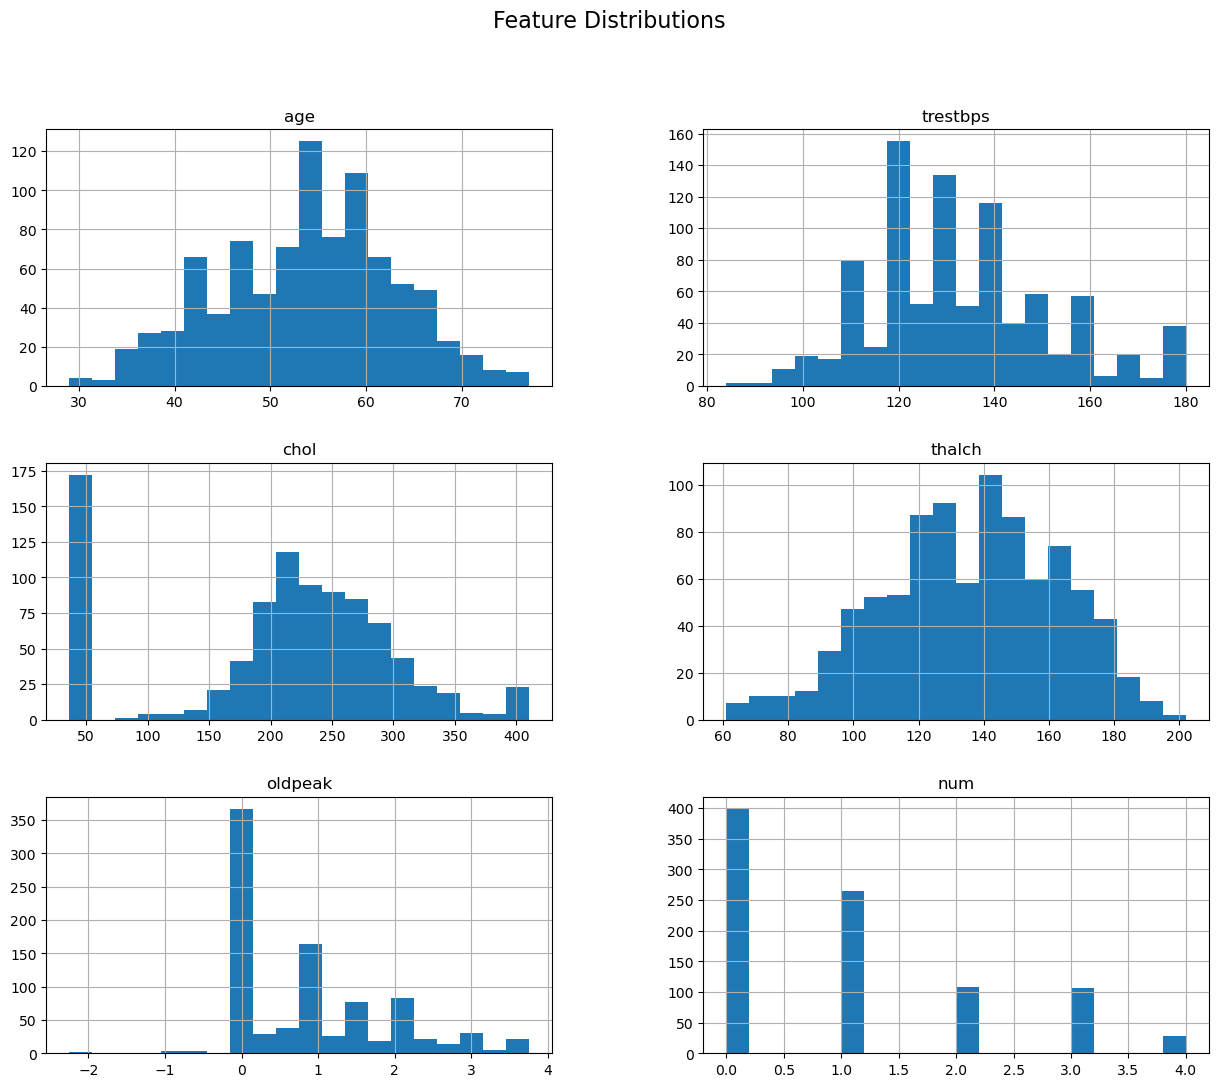

In [16]:
# Histogram
df.hist(figsize=(15,12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [17]:
#Feature & Target Separation
features= df.drop(columns=['num'])
target= df[['num']]

In [18]:
# Splitting the dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(725, 12)
(182, 12)
(725, 1)
(182, 1)


In [19]:
# Dealing with data inconsistency
x_train['exang'].unique()

array([False, True, 'TURE', 'FALSE'], dtype=object)

In [20]:
# converting datatype into string for uniformity as some are boolean
x_train['exang'] = x_train['exang'].astype(str)
x_test['exang'] = x_test['exang'].astype(str)

In [21]:
x_train['exang'] = x_train['exang'].replace({'TURE': 'TRUE'})
x_test['exang'] = x_test['exang'].replace({'TURE': 'TRUE'})
x_train['exang'] = x_train['exang'].replace({'True': 'TRUE'})
x_test['exang'] = x_test['exang'].replace({'True': 'TRUE'})
x_train['exang'] = x_train['exang'].replace({'False': 'FALSE'})
x_test['exang'] = x_test['exang'].replace({'False': 'FALSE'})

In [22]:
x_train['exang'].unique() # data corrected

array(['FALSE', 'TRUE'], dtype=object)

In [23]:
one_hot=OneHotEncoder()
# Applying one hot encoder separately on training and testing data
df1=pd.DataFrame(one_hot.fit_transform(x_train[['sex']]).toarray(),columns=['Male','Female'],index=x_train.index)
df_1=pd.DataFrame(one_hot.transform(x_test[['sex']]).toarray(),columns=['Male','Female'], index=x_test.index)


In [24]:
df_train = pd.concat([x_train,df1], axis=1)
df_test = pd.concat([x_test,df_1], axis=1)
# Drop original categorical columns
df_train.drop(columns=['sex'], inplace=True)
df_test.drop(columns=['sex'], inplace=True)

In [25]:
df_train

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,Male,Female
803,48,asymptomatic,124.0,274.00,False,lv hypertrophy,166.0,FALSE,0.50,flat,reversable defect,0.0,1.0
690,56,asymptomatic,120.0,36.25,False,st-t abnormality,100.0,TRUE,-1.00,downsloping,reversable defect,0.0,1.0
322,59,atypical angina,140.0,287.00,False,normal,150.0,FALSE,0.00,upsloping,normal,0.0,1.0
164,65,asymptomatic,120.0,177.00,False,normal,140.0,FALSE,0.40,upsloping,reversable defect,0.0,1.0
414,60,non-anginal,140.0,185.00,False,lv hypertrophy,155.0,FALSE,3.00,flat,normal,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,56,non-anginal,155.0,36.25,False,st-t abnormality,99.0,FALSE,0.00,flat,normal,0.0,1.0
517,64,asymptomatic,120.0,36.25,True,st-t abnormality,106.0,FALSE,2.00,flat,fixed defect,0.0,1.0
821,68,non-anginal,180.0,274.00,True,lv hypertrophy,150.0,TRUE,1.60,flat,reversable defect,0.0,1.0
511,59,asymptomatic,122.0,233.00,False,normal,117.0,TRUE,1.30,downsloping,reversable defect,0.0,1.0


In [26]:
# using ordinal encoder
ord_enc= OrdinalEncoder()
df_train[['cp','slope','restecg','thal','fbs','exang']]= ord_enc.fit_transform(x_train[['cp','slope','restecg','thal','fbs','exang']])
df_test[['cp','slope','restecg','thal','fbs','exang']]= ord_enc.transform(x_test[['cp','slope','restecg','thal','fbs','exang']])

In [27]:
df_train.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,Male,Female
803,48,0.0,124.0,274.00,0.0,0.0,166.0,0.0,0.5,1.0,2.0,0.0,1.0
690,56,0.0,120.0,36.25,0.0,2.0,100.0,1.0,-1.0,0.0,2.0,0.0,1.0
322,59,1.0,140.0,287.00,0.0,1.0,150.0,0.0,0.0,2.0,1.0,0.0,1.0
164,65,0.0,120.0,177.00,0.0,1.0,140.0,0.0,0.4,2.0,2.0,0.0,1.0
414,60,2.0,140.0,185.00,0.0,0.0,155.0,0.0,3.0,1.0,1.0,0.0,1.0


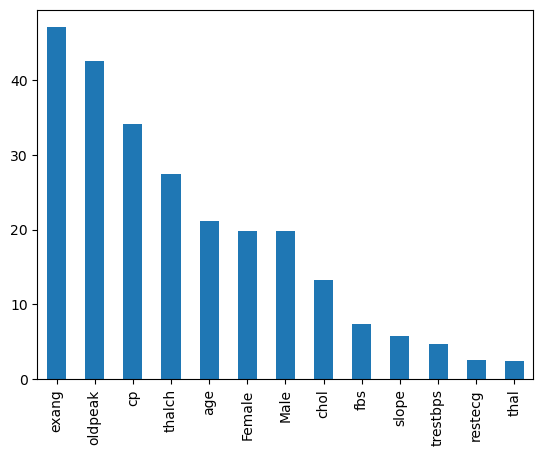

In [28]:
#Feature selection using f_classif as target is numerical 
f_clas= f_classif(df_train,y_train)
pd.Series(f_clas[0],index=df_train.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [33]:
#feature selection cross verification using chiz
chi= chi2(df_train[['restecg','thal','trestbps','fbs','slope']],y_train)
pd.Series(chi[0],index=['restecg','thal','trestbps','fbs','slope'])

restecg      4.115992
thal         4.767154
trestbps    51.465583
fbs         22.549025
slope        9.262504
dtype: float64

In [34]:
# dropping the least important features
df_train.drop(columns=['restecg','thal','slope'],inplace=True)
df_test.drop(columns=['restecg','thal','slope'],inplace=True)

In [35]:
df_train

,age,cp,trestbps,chol,fbs,thalch,exang,oldpeak,Male,Female
803,48,0.0,124.0,274.00,0.0,166.0,0.0,0.50,0.0,1.0
690,56,0.0,120.0,36.25,0.0,100.0,1.0,-1.00,0.0,1.0
322,59,1.0,140.0,287.00,0.0,150.0,0.0,0.00,0.0,1.0
164,65,0.0,120.0,177.00,0.0,140.0,0.0,0.40,0.0,1.0
414,60,2.0,140.0,185.00,0.0,155.0,0.0,3.00,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
678,56,2.0,155.0,36.25,0.0,99.0,0.0,0.00,0.0,1.0
517,64,0.0,120.0,36.25,1.0,106.0,0.0,2.00,0.0,1.0
821,68,2.0,180.0,274.00,1.0,150.0,1.0,1.60,0.0,1.0
511,59,0.0,122.0,233.00,0.0,117.0,1.0,1.30,0.0,1.0


In [36]:
# Feature Scaling
std_sca=StandardScaler()
df_train[['age','trestbps','chol','thalch']]= std_sca.fit_transform(x_train[['age','trestbps','chol','thalch']]) # for training use fit_transform
# Scaling x test features
df_test[['age','trestbps','chol','thalch']]= std_sca.transform(x_test[['age','trestbps','chol','thalch']])# for testing use tranform


In [37]:
df_test.head()

,age,cp,trestbps,chol,fbs,thalch,exang,oldpeak,Male,Female
500,0.579265,0.0,2.341315,-1.750559,1.0,-0.601266,1.0,0.0,0.0,1.0
202,1.360080,2.0,-1.200689,0.060756,1.0,-1.382147,1.0,1.3,0.0,1.0
714,-0.313095,0.0,-0.158923,1.003562,0.0,0.216800,1.0,1.2,1.0,0.0
477,1.136990,2.0,-0.419365,1.044553,0.0,-0.192233,1.0,1.8,0.0,1.0
541,-0.647731,0.0,1.403726,1.249511,0.0,-1.642441,1.0,1.5,0.0,1.0


In [40]:
#### Model Training and validation
dec_tree=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=7)
dec_tree.fit(df_train,y_train)
y_pred= dec_tree.predict(df_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5824175824175825

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80        80
           1       0.51      0.42      0.46        53
           2       0.35      0.50      0.42        22
           3       0.27      0.14      0.19        21
           4       0.20      0.17      0.18         6

    accuracy                           0.58       182
   macro avg       0.42      0.42      0.41       182
weighted avg       0.56      0.58      0.56       182



In [44]:
# Model Training and validation 
dec_tree=DecisionTreeClassifier(criterion='gini',
    splitter='best',
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=8,
    random_state=10,
    max_leaf_nodes=None,)
dec_tree.fit(df_train,y_train)
y_pred= dec_tree.predict(df_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5164835164835165

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.81      0.73        80
           1       0.41      0.34      0.37        53
           2       0.28      0.23      0.25        22
           3       0.25      0.19      0.22        21
           4       0.40      0.33      0.36         6

    accuracy                           0.52       182
   macro avg       0.40      0.38      0.39       182
weighted avg       0.48      0.52      0.49       182



In [46]:
# Model Training and validation 
dec_tree=DecisionTreeClassifier(criterion='entropy',
    splitter='random',
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=8,
    random_state=10,
    max_leaf_nodes=None,)
dec_tree.fit(df_train,y_train)
y_pred= dec_tree.predict(df_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.4835164835164835

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.79      0.70        80
           1       0.38      0.40      0.39        53
           2       0.21      0.14      0.17        22
           3       0.08      0.05      0.06        21
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.26      0.27      0.26       182
weighted avg       0.42      0.48      0.45       182



In [48]:
# Gridsearch used to find best values for hyperparamters

In [49]:
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,6)}

In [51]:
grid_search=GridSearchCV(estimator=dec_tree,param_grid=params,cv=5)
grid_search.fit(df_train,y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy', max_depth=7,
                                              max_features=8, random_state=10,
                                              splitter='random'),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 6),
                         'splitter': ['best', 'random']})

In [52]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 3, 'splitter': 'random'}

In [53]:
#### Model Training and validation
dec_tree=DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=3)
dec_tree.fit(df_train,y_train)
y_pred= dec_tree.predict(df_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4835164835164835

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.81      0.70        80
           1       0.35      0.32      0.33        53
           2       0.22      0.27      0.24        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.24      0.28      0.26       182
weighted avg       0.40      0.48      0.43       182



In [57]:
df1= df.copy()
df1['num'] = df['num'].replace({
    0: 'No Disease',
    1: 'Stage 1',
    2: 'Stage 2',
    3: 'Stage 3',
    4: 'Stage 4'
})
df1

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145.0,233.00,True,lv hypertrophy,150.0,False,2.300000,downsloping,fixed defect,No Disease
1,41,Male,atypical angina,135.0,203.00,False,normal,132.0,False,0.000000,flat,fixed defect,No Disease
2,57,Male,asymptomatic,140.0,192.00,False,normal,148.0,False,0.400000,flat,fixed defect,No Disease
3,52,Male,typical angina,118.0,186.00,False,lv hypertrophy,190.0,False,0.000000,flat,fixed defect,No Disease
4,57,Male,asymptomatic,110.0,201.00,False,normal,126.0,True,1.500000,flat,fixed defect,No Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,Male,asymptomatic,125.0,36.25,False,normal,120.0,False,1.500000,upsloping,normal,Stage 4
903,62,Male,asymptomatic,166.0,170.00,False,st-t abnormality,120.0,True,3.000000,flat,reversable defect,Stage 4
904,56,Male,non-anginal,170.0,36.25,False,lv hypertrophy,123.0,True,2.500000,downsloping,reversable defect,Stage 4
905,56,Male,non-anginal,144.0,208.00,True,st-t abnormality,105.0,TURE,0.891253,downsloping,reversable defect,Stage 4


<Figure size 2400x1000 with 0 Axes>

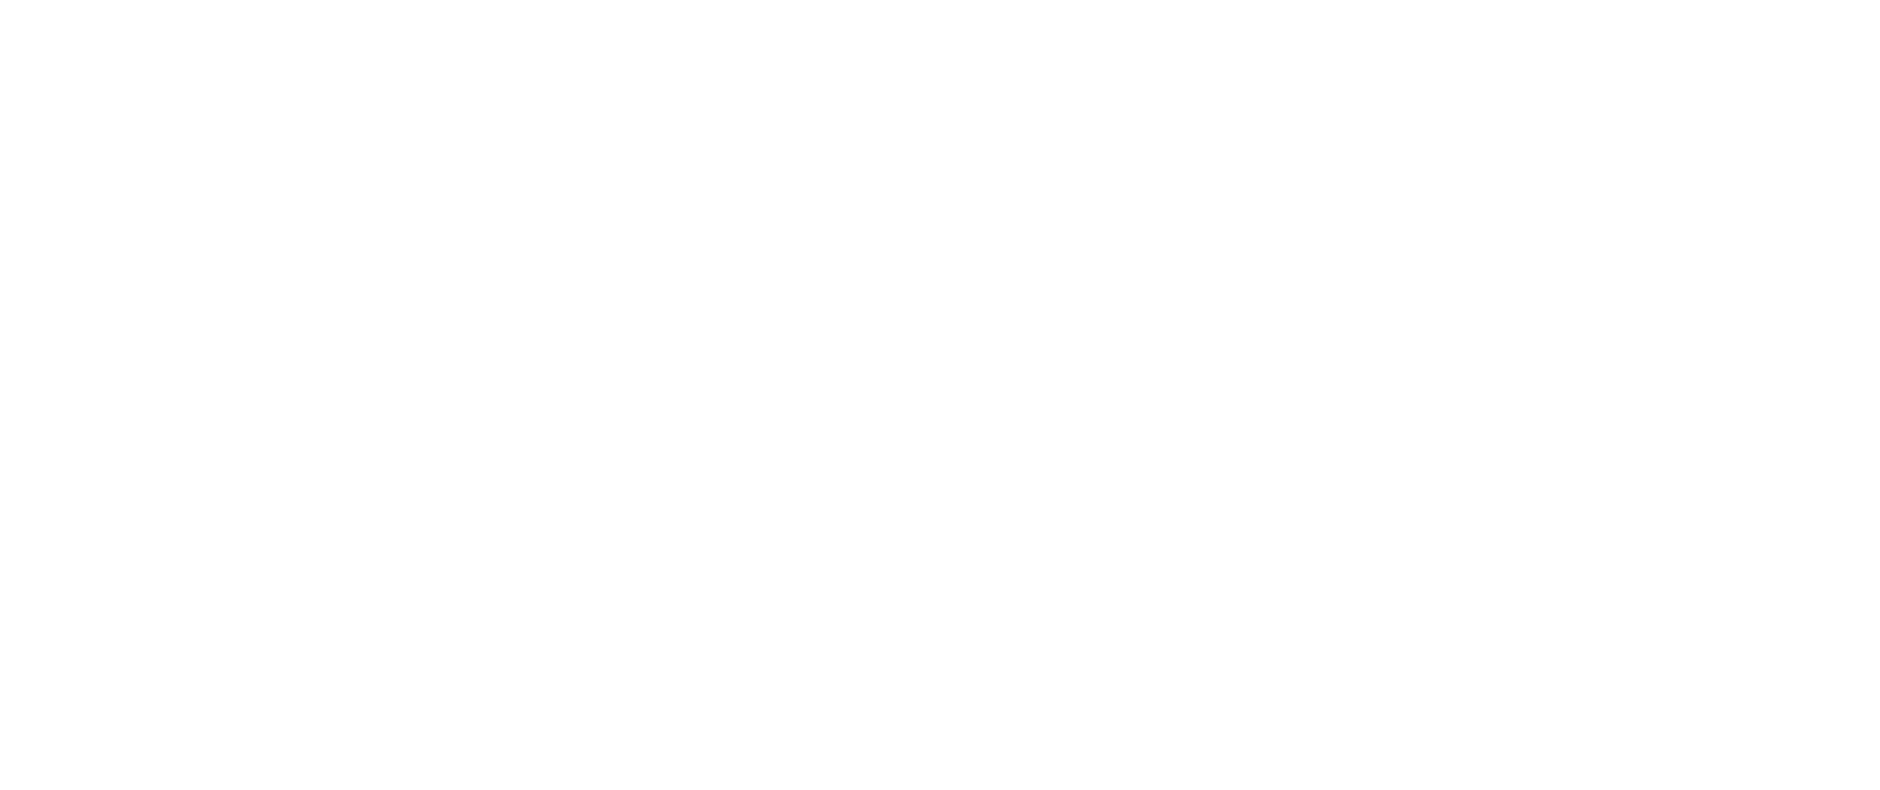

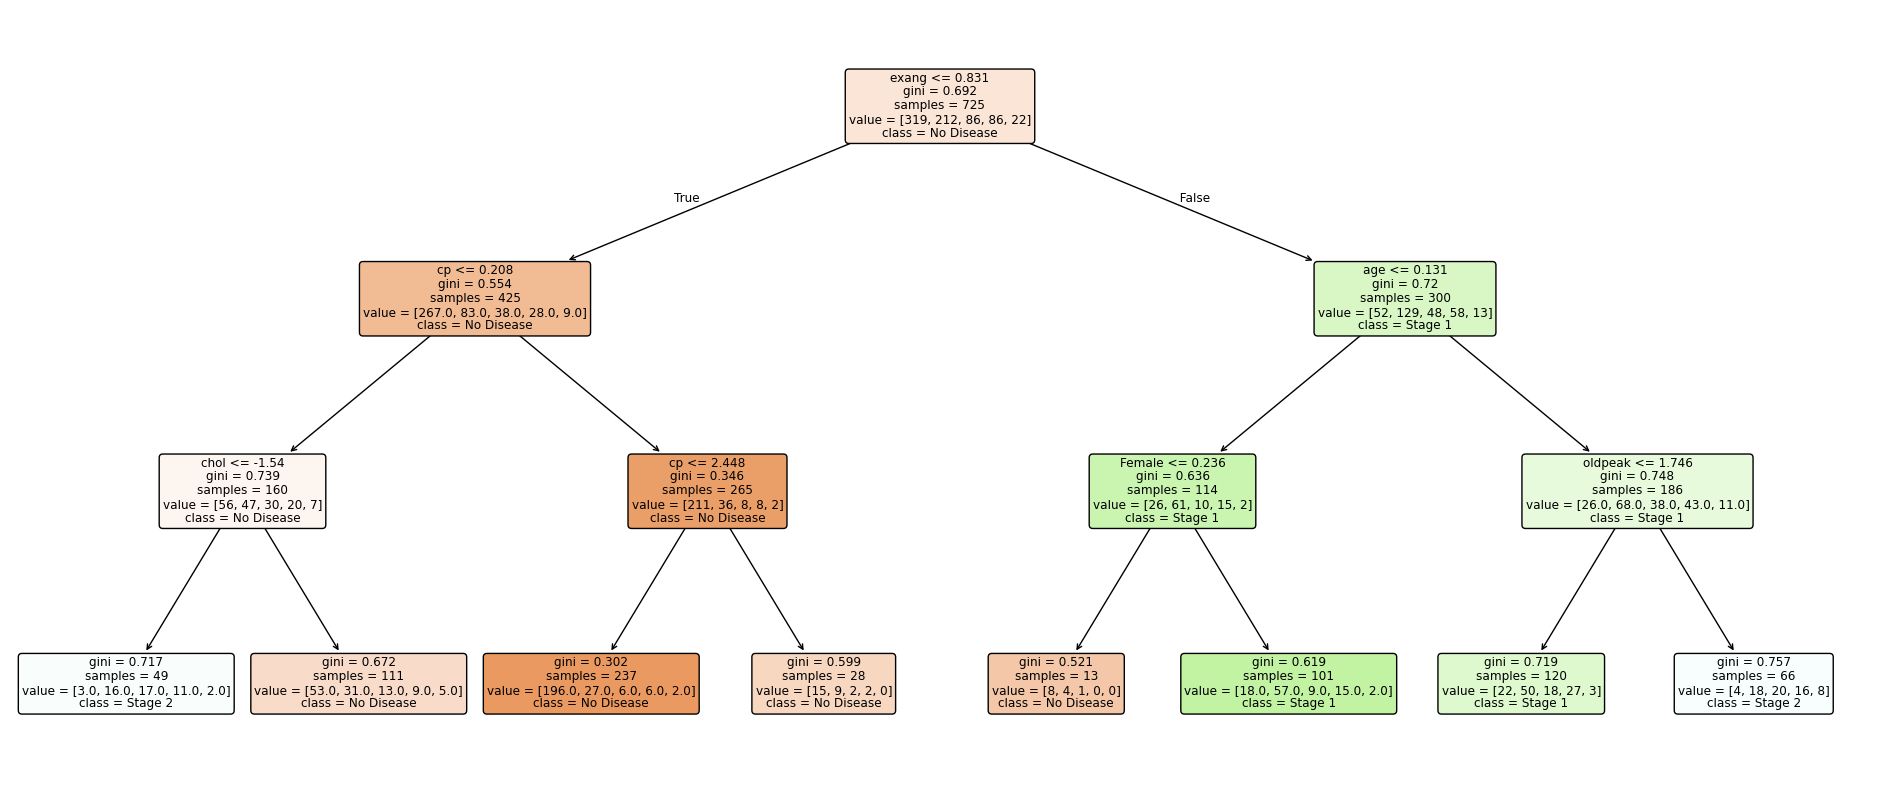

In [58]:
# Visualise decision tree
plt.figure(figsize=(24,10))
plot_tree(dec_tree,filled=True,feature_names=list(df_train),class_names=df1.num.unique(),rounded=True,max_depth=3)
plt.show();